In [1]:
import os
import sys

import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob

import tensorflow as tf 
import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
with open("D:/PartAnnotation/metadata.json") as json_file:
    metadata = json.load(json_file)

print(metadata)

{'Airplane': {'directory': '02691156', 'lables': ['wing', 'body', 'tail', 'engine'], 'colors': ['blue', 'green', 'red', 'pink']}, 'Bag': {'directory': '02773838', 'lables': ['handle', 'body'], 'colors': ['blue', 'green']}, 'Cap': {'directory': '02954340', 'lables': ['panels', 'peak'], 'colors': ['blue', 'green']}, 'Car': {'directory': '02958343', 'lables': ['wheel', 'hood', 'roof'], 'colors': ['blue', 'green', 'red']}, 'Chair': {'directory': '03001627', 'lables': ['leg', 'arm', 'back', 'seat'], 'colors': ['blue', 'green', 'red', 'pink']}, 'Earphone': {'directory': '03261776', 'lables': ['earphone', 'headband'], 'colors': ['blue', 'green']}, 'Guitar': {'directory': '03467517', 'lables': ['head', 'body', 'neck'], 'colors': ['blue', 'green', 'red']}, 'Knife': {'directory': '03624134', 'lables': ['handle', 'blade'], 'colors': ['blue', 'green']}, 'Lamp': {'directory': '03636649', 'lables': ['canopy', 'lampshade', 'base'], 'colors': ['blue', 'green', 'red']}, 'Laptop': {'directory': '0364280

In [3]:
points_dir = "D:/PartAnnotation/{}/points".format(
    metadata["Workpiece_test7"]["directory"]
)
labels_dir = "D:/PartAnnotation/{}/points_label".format(
    metadata["Workpiece_test7"]["directory"]
)
LABELS = metadata["Workpiece_test7"]["lables"]
COLORS = metadata["Workpiece_test7"]["colors"]

# VAL_SPLIT = 0.2
NUM_SAMPLE_POINTS = 2048 #1024
# BATCH_SIZE = 1
# EPOCHS = 100
# INITIAL_LR = 1e-3

In [4]:
point_clouds, test_point_clouds = [], []
point_cloud_labels, all_labels = [], []

points_files = glob(os.path.join(points_dir, "*.txt"))

for point_file in tqdm(points_files):
    cloud = np.loadtxt(point_file)
    point_cloud = cloud[:, :3]
    labels = cloud[:, 3]
    label_data = keras.utils.to_categorical(labels, num_classes=len(LABELS)+1)
    point_clouds.append(point_cloud)
    point_cloud_labels.append(label_data)
    
    labels_txt = []
    for i in range(len(labels)):
        if cloud[i, 3] == 0:
            labels_txt.append('workpiece')
        elif cloud[i, 3] == 1:
            labels_txt.append('weldbead')
            
    all_labels.append(labels_txt)
    
    

100%|██████████| 1889/1889 [58:00<00:00,  1.84s/it] 


In [5]:
for _ in range(5):
    i = random.randint(0, len(point_clouds) - 1)
    print(f"point_clouds[{i}].shape:", point_clouds[0].shape)
    print(f"point_cloud_labels[{i}].shape:", point_cloud_labels[0].shape)
    for j in range(5):
        print(
            f"all_labels[{i}][{j}]:",
            all_labels[i][j],
            f"\tpoint_cloud_labels[{i}][{j}]:",
            point_cloud_labels[i][j],
            "\n",
        )

point_clouds[1044].shape: (265682, 3)
point_cloud_labels[1044].shape: (265682, 3)
all_labels[1044][0]: workpiece 	point_cloud_labels[1044][0]: [1. 0. 0.] 

all_labels[1044][1]: workpiece 	point_cloud_labels[1044][1]: [1. 0. 0.] 

all_labels[1044][2]: workpiece 	point_cloud_labels[1044][2]: [1. 0. 0.] 

all_labels[1044][3]: workpiece 	point_cloud_labels[1044][3]: [1. 0. 0.] 

all_labels[1044][4]: workpiece 	point_cloud_labels[1044][4]: [1. 0. 0.] 

point_clouds[1202].shape: (265682, 3)
point_cloud_labels[1202].shape: (265682, 3)
all_labels[1202][0]: workpiece 	point_cloud_labels[1202][0]: [1. 0. 0.] 

all_labels[1202][1]: workpiece 	point_cloud_labels[1202][1]: [1. 0. 0.] 

all_labels[1202][2]: workpiece 	point_cloud_labels[1202][2]: [1. 0. 0.] 

all_labels[1202][3]: workpiece 	point_cloud_labels[1202][3]: [1. 0. 0.] 

all_labels[1202][4]: workpiece 	point_cloud_labels[1202][4]: [1. 0. 0.] 

point_clouds[1225].shape: (265682, 3)
point_cloud_labels[1225].shape: (265682, 3)
all_labels[122

In [6]:
# point_clouds, test_point_clouds = [], []
# point_cloud_labels, all_labels = [], []

# points_files = glob(os.path.join(points_dir, "*.txt"))

# for point_file in tqdm(points_files):
#     point_cloud = np.loadtxt(point_file)
#     #point_cloud = point_cloud[:, :3]
#     if point_cloud.shape[0] < NUM_SAMPLE_POINTS:
#         continue

#     # Get the file-id of the current point cloud for parsing its
#     # labels.
#     #file_id = point_file.split("/")[-1].split(".")[0]
#     file_id = os.path.basename(point_file).split(".")[0]
#     label_data, num_labels = {}, 0
#     for label in LABELS:
#         label_file = os.path.join(labels_dir, label, file_id + ".txt")
#         if os.path.exists(label_file):
#             label_data[label] = np.loadtxt(label_file).astype("float32")
#             #label_data[label] = label_data[:, 3]
#             num_labels = len(label_data[label])

#     # Point clouds having labels will be our training samples.
#     try:
#         label_map = ["none"] * num_labels
#         for label in LABELS:
#             for i, data in enumerate(label_data[label]):
#                 label_map[i] = label if data == 1 else label_map[i]
#         label_data = [
#             LABELS.index(label) if label != "none" else len(LABELS)
#             for label in label_map
#         ]
#         # Apply one-hot encoding to the dense label representation.
#         label_data = keras.utils.to_categorical(label_data, num_classes=len(LABELS) + 1)

#         point_clouds.append(point_cloud)
#         point_cloud_labels.append(label_data)
#         all_labels.append(label_map)
#     except KeyError:
#         test_point_clouds.append(point_cloud)


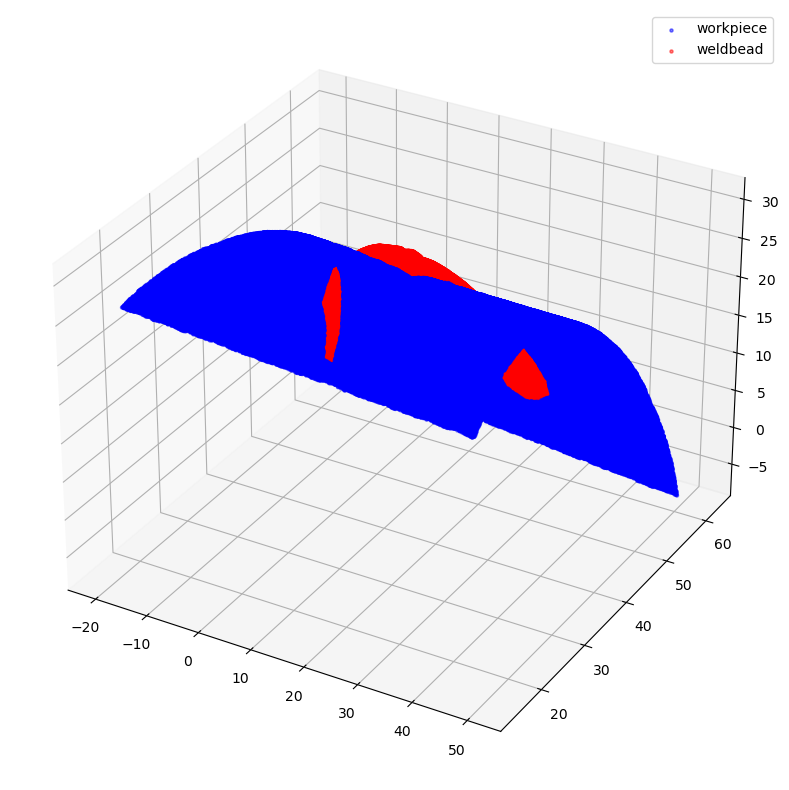

In [7]:
def visualize_data(point_cloud, labels):
    df = pd.DataFrame(
        data={
            "x": point_cloud[:, 0],
            "y": point_cloud[:, 1],
            "z": point_cloud[:, 2],
            "label": labels,
        }
    )
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection="3d")
    for index, label in enumerate(LABELS):
        c_df = df[df["label"] == label]
        try:
            ax.scatter(
                c_df["x"], c_df["y"], c_df["z"], label=label, alpha=0.5, c=COLORS[index], s=5
            )
        except IndexError:
            pass
    ax.legend()
#     ax.view_init(elev=180) 
    plt.show()

visualize_data(point_clouds[20], all_labels[20])



In [8]:
for index in tqdm(range(len(point_clouds))):
    current_point_cloud = point_clouds[index]
    current_label_cloud = point_cloud_labels[index]
    current_labels = all_labels[index]
    num_points = len(current_point_cloud)
    # Randomly sampling respective indices.
    sampled_indices = random.sample(list(range(num_points)), NUM_SAMPLE_POINTS)
    # Sampling points corresponding to sampled indices.
    sampled_point_cloud = np.array([current_point_cloud[i] for i in sampled_indices])
    # Sampling corresponding one-hot encoded labels.
    sampled_label_cloud = np.array([current_label_cloud[i] for i in sampled_indices])
    # Sampling corresponding labels for visualization.
    sampled_labels = np.array([current_labels[i] for i in sampled_indices])
    # Normalizing sampled point cloud.
    norm_point_cloud = sampled_point_cloud - np.mean(sampled_point_cloud, axis=0)
    norm_point_cloud /= np.max(np.linalg.norm(norm_point_cloud, axis=1))
    point_clouds[index] = norm_point_cloud
    point_cloud_labels[index] = sampled_label_cloud
    all_labels[index] = sampled_labels

# from scipy.spatial import KDTree

# def farthest_point_sampling(point_cloud, num_sample_points):
#     num_points = point_cloud.shape[0]
#     sampled_points = np.zeros((num_sample_points, point_cloud.shape[1]))
#     distances = np.full(num_points, float('inf'))

#     # 使用 KDTree 加速最近鄰查找
#     tree = KDTree(point_cloud)

#     # 隨機選擇第一個點
#     farthest_index = random.randint(0, num_points - 1)
#     sampled_points[0] = point_cloud[farthest_index]

#     for i in range(1, num_sample_points):
#         current_point = sampled_points[i - 1]
#         dist, idx = tree.query(current_point, k=num_points)
#         distances = np.minimum(distances, dist)

#         farthest_index = np.argmax(distances)
#         sampled_points[i] = point_cloud[farthest_index]

#     return sampled_points

# for index in tqdm(range(len(point_clouds))):
#     current_point_cloud = point_clouds[index]
#     current_label_cloud = point_cloud_labels[index]
#     current_labels = all_labels[index]

#     # Perform farthest point sampling
#     sampled_point_cloud = farthest_point_sampling(current_point_cloud, NUM_SAMPLE_POINTS)

#     # Find the indices of the sampled points
#     sampled_indices = [np.where((current_point_cloud == point).all(axis=1))[0][0] for point in sampled_point_cloud]

#     # Sampling corresponding one-hot encoded labels
#     sampled_label_cloud = np.array([current_label_cloud[i] for i in sampled_indices])
    
#     # Sampling corresponding labels for visualization
#     sampled_labels = np.array([current_labels[i] for i in sampled_indices])

#     # Normalizing sampled point cloud
#     norm_point_cloud = sampled_point_cloud - np.mean(sampled_point_cloud, axis=0)
#     norm_point_cloud /= np.max(np.linalg.norm(norm_point_cloud, axis=1))
    
#     point_clouds[index] = norm_point_cloud
#     point_cloud_labels[index] = sampled_label_cloud
#     all_labels[index] = sampled_labels

# for index in tqdm(range(len(point_clouds))):
#     current_point_cloud = point_clouds[index]
#     current_label_cloud = point_cloud_labels[index]
#     current_labels = all_labels[index]
#     num_points = len(current_point_cloud)

#     # 獲取標籤為weldbead和workpiece的點的索引
#     indices_weldbead = [i for i in range(num_points) if current_labels[i] == 'weldbead']
#     indices_workpiece = [i for i in range(num_points) if current_labels[i] == 'workpiece']

#     # 分別抽樣30%的weldbead點和70%的workpiece點
#     num_sample_weldbead = int(NUM_SAMPLE_POINTS * 0.3)
#     num_sample_workpiece = NUM_SAMPLE_POINTS - num_sample_weldbead

#     sampled_indices_weldbead = random.sample(indices_weldbead, min(num_sample_weldbead, len(indices_weldbead)))
#     sampled_indices_workpiece = random.sample(indices_workpiece, min(num_sample_workpiece, len(indices_workpiece)))

#     # 合併兩類點的索引
#     sampled_indices = sampled_indices_weldbead + sampled_indices_workpiece

#     # 進行點雲和標籤的抽樣
#     sampled_point_cloud = np.array([current_point_cloud[i] for i in sampled_indices])
#     sampled_label_cloud = np.array([current_label_cloud[i] for i in sampled_indices])
#     sampled_labels = np.array([current_labels[i] for i in sampled_indices])

#     # 正規化抽樣的點雲
#     norm_point_cloud = sampled_point_cloud - np.mean(sampled_point_cloud, axis=0)
#     norm_point_cloud /= np.max(np.linalg.norm(norm_point_cloud, axis=1))

#     # 更新資料
#     point_clouds[index] = norm_point_cloud
#     point_cloud_labels[index] = sampled_label_cloud
#     all_labels[index] = sampled_labels

100%|██████████| 1889/1889 [00:48<00:00, 38.90it/s] 


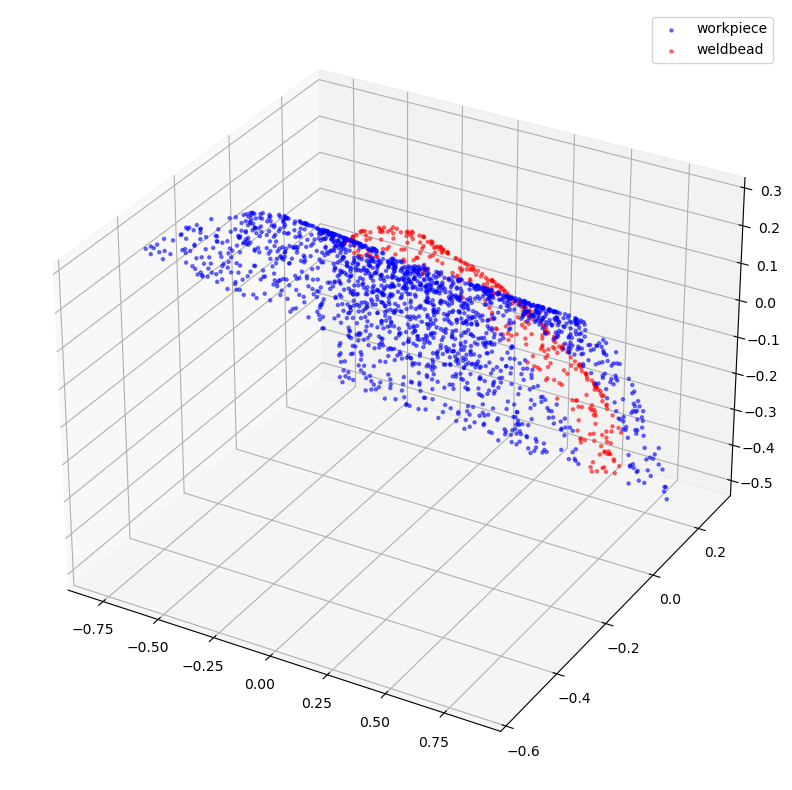

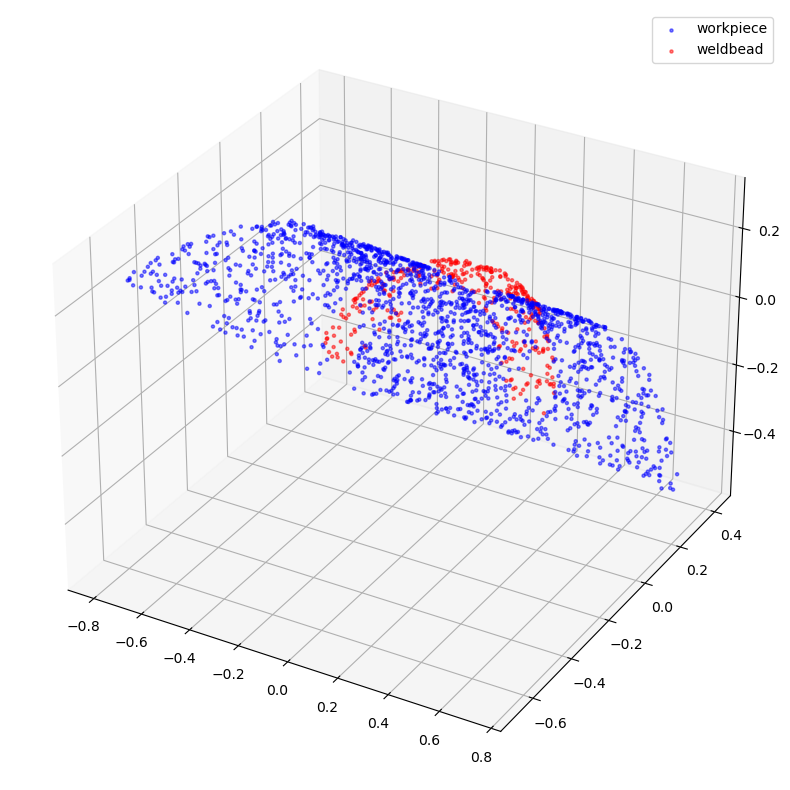

In [9]:
visualize_data(point_clouds[80], all_labels[80])
visualize_data(point_clouds[50], all_labels[50])

In [10]:
VAL_SPLIT = 0.2 #1024
BATCH_SIZE = 8
EPOCHS = 200
INITIAL_LR = 1e-3

def load_data(point_cloud_batch, label_cloud_batch):
    point_cloud_batch.set_shape([NUM_SAMPLE_POINTS, 3])
    label_cloud_batch.set_shape([NUM_SAMPLE_POINTS, len(LABELS)+1])
    return point_cloud_batch, label_cloud_batch


def augment(point_cloud_batch, label_cloud_batch):
    noise = tf.random.uniform(
        tf.shape(label_cloud_batch), -0.001, 0.001, dtype=tf.float64
    )
    point_cloud_batch += noise[:, :, :3]
    return point_cloud_batch, label_cloud_batch


def generate_dataset(point_clouds, label_clouds, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((point_clouds, label_clouds))
    dataset = dataset.shuffle(BATCH_SIZE * 100) if is_training else dataset
    dataset = dataset.map(load_data, num_parallel_calls=-1)
    dataset = dataset.batch(batch_size=BATCH_SIZE)
    dataset = (
        dataset.map(augment, num_parallel_calls=-1)
        if is_training
        else dataset
    )
    return dataset


split_index = int(len(point_clouds) * (1 - VAL_SPLIT))
train_point_clouds = point_clouds[:split_index]
train_label_cloud = point_cloud_labels[:split_index]
total_training_examples = len(train_point_clouds)

val_point_clouds = point_clouds[split_index:]
val_label_cloud = point_cloud_labels[split_index:]

print("Num train point clouds:", len(train_point_clouds))
print("Num train point cloud labels:", len(train_label_cloud))
print("Num val point clouds:", len(val_point_clouds))
print("Num val point cloud labels:", len(val_label_cloud))

train_dataset = generate_dataset(train_point_clouds, train_label_cloud)
val_dataset = generate_dataset(val_point_clouds, val_label_cloud, is_training=False)

print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)

Num train point clouds: 1511
Num train point cloud labels: 1511
Num val point clouds: 378
Num val point cloud labels: 378
Train Dataset: <ParallelMapDataset shapes: ((None, 2048, 3), (None, 2048, 3)), types: (tf.float64, tf.float32)>
Validation Dataset: <BatchDataset shapes: ((None, 2048, 3), (None, 2048, 3)), types: (tf.float64, tf.float32)>


In [11]:
def conv_block(x, filters, name):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid", name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def mlp_block(x, filters, name):
    x = layers.Dense(filters, name=f"{name}_dense")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)

# class OrthogonalRegularizer(keras.regularizers.Regularizer):
#     """Reference: https://keras.io/examples/vision/pointnet/#build-a-model"""

#     def __init__(self, num_features, l2reg=0.001):
#         self.num_features = num_features
#         self.l2reg = l2reg
#         self.identity = tf.eye(num_features)

#     def __call__(self, x):
#         x = tf.reshape(x, (-1, self.num_features, self.num_features))
#         xxt = tf.tensordot(x, x, axes=(2, 2))
#         xxt = tf.reshape(xxt, (-1, self.num_features, self.num_features))
#         return tf.reduce_sum(self.l2reg * tf.square(xxt - self.identity))

#     def get_config(self):
#         config = super().get_config()
#         config.update({"num_features": self.num_features, "l2reg_strength": self.l2reg})
#         return config

class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """Reference: https://keras.io/examples/vision/pointnet/#build-a-model"""

    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.identity = tf.eye(num_features)

    def __call__(self, x):
        x = tf.reshape(x, (-1, self.num_features, self.num_features))
        xxt = tf.tensordot(x, x, axes=(2, 2))
        xxt = tf.reshape(xxt, (-1, self.num_features, self.num_features))
        return tf.reduce_sum(self.l2reg * tf.square(xxt - self.identity))

    def get_config(self):
        # 沒有調用 super().get_config()，因為 Regularizer 類的 get_config 方法沒有返回任何東西
        config = {"num_features": self.num_features, "l2reg_strength": self.l2reg}
        return config

def transformation_net(inputs, num_features, name):
    """
    Reference: https://keras.io/examples/vision/pointnet/#build-a-model.

    The `filters` values come from the original paper:
    https://arxiv.org/abs/1612.00593.
    """
    x = conv_block(inputs, filters=64, name=f"{name}_1")
    x = conv_block(x, filters=128, name=f"{name}_2")
    x = conv_block(x, filters=1024, name=f"{name}_3")
    x = layers.GlobalMaxPooling1D()(x)
    x = mlp_block(x, filters=512, name=f"{name}_1_1")
    x = mlp_block(x, filters=256, name=f"{name}_2_1")
    return layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=keras.initializers.Constant(np.eye(num_features).flatten()),
        activity_regularizer=OrthogonalRegularizer(num_features),
        name=f"{name}_final",
    )(x)


def transformation_block(inputs, num_features, name):
    transformed_features = transformation_net(inputs, num_features, name=name)
    transformed_features = layers.Reshape((num_features, num_features))(
        transformed_features
    )
    return layers.Dot(axes=(2, 1), name=f"{name}_mm")([inputs, transformed_features])

def get_shape_segmentation_model(num_points, num_classes):
    input_points = keras.Input(shape=(None, 3))

    # PointNet Classification Network.
    transformed_inputs = transformation_block(
        input_points, num_features=3, name="input_transformation_block"
    )
    features_64 = conv_block(transformed_inputs, filters=64, name="features_64")
    features_128_1 = conv_block(features_64, filters=128, name="features_128_1")
    features_128_2 = conv_block(features_128_1, filters=128, name="features_128_2")
    transformed_features = transformation_block(
        features_128_2, num_features=128, name="transformed_features"
    )
    features_512 = conv_block(transformed_features, filters=512, name="features_512")
    features_2048 = conv_block(features_512, filters=2048, name="pre_maxpool_block") 
    global_features = layers.MaxPool1D(pool_size=num_points, name="global_features")(
        features_2048
    )
    global_features = tf.tile(global_features, [1, num_points, 1])

    # Segmentation head.
    segmentation_input = layers.Concatenate(name="segmentation_input")(
        [
            features_64,
            features_128_1,
            features_128_2,
            transformed_features,
            features_512,
            global_features,
        ]
    )
    segmentation_features = conv_block(
        segmentation_input, filters=128, name="segmentation_features"
    )
    outputs = layers.Conv1D(
        num_classes, kernel_size=1, activation="softmax", name="segmentation_head"
    )(segmentation_features)
    return keras.Model(input_points, outputs)

x, y = next(iter(train_dataset))

num_points = x.shape[1]
num_classes = y.shape[-1]

segmentation_model = get_shape_segmentation_model(num_points, num_classes)
segmentation_model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, None, 3)]    0                                            
__________________________________________________________________________________________________
input_transformation_block_1_co (None, None, 64)     256         input_1[0][0]                    
__________________________________________________________________________________________________
input_transformation_block_1_ba (None, None, 64)     256         input_transformation_block_1_conv
__________________________________________________________________________________________________
input_transformation_block_1_re (None, None, 64)     0           input_transformation_block_1_batc
_______________________________________________________________________________________

Steps per epoch: 188.
Total training steps: 37600.


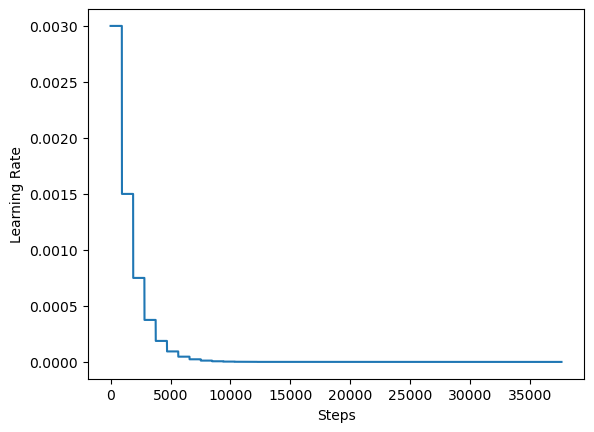

In [12]:
steps_per_epoch = total_training_examples // BATCH_SIZE
total_training_steps = steps_per_epoch * EPOCHS
print(f"Steps per epoch: {steps_per_epoch}.")
print(f"Total training steps: {total_training_steps}.")

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.003,
    decay_steps=steps_per_epoch * 5,
    decay_rate=0.5,
    staircase=True,
)

steps = range(total_training_steps)
lrs = [lr_schedule(step) for step in steps]

plt.plot(lrs)
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.show()

In [13]:
# def run_experiment(epochs):
#     segmentation_model = get_shape_segmentation_model(num_points, num_classes)
#     segmentation_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
#         loss=keras.losses.CategoricalCrossentropy(),
#         metrics=["accuracy"],
#     )

#     checkpoint_filepath = "test_checkpoint.weights.h5"
#     checkpoint_callback = keras.callbacks.ModelCheckpoint(
#         checkpoint_filepath,
#         monitor="val_loss",
#         save_best_only=True,
#         save_weights_only=True,
#     )

#     history = segmentation_model.fit(
#         train_dataset,
#         validation_data=val_dataset,
#         epochs=epochs,
#         callbacks=[checkpoint_callback],
#     )

#     segmentation_model.load_weights(checkpoint_filepath)
#     return segmentation_model, history


# segmentation_model, history = run_experiment(epochs=EPOCHS)

def run_experiment(epochs):
    segmentation_model = get_shape_segmentation_model(num_points, num_classes)
    segmentation_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    checkpoint_filepath = "test_checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    early_stopping_callback = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",  # 監控驗證集準確率
        patience=40,  # 若連續10次epoch準確率都沒上升時停止訓練
        restore_best_weights=True  # 自動恢復最佳模型權重
    )

    history = segmentation_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[checkpoint_callback, early_stopping_callback],  # 加入早停回調
    )

    return segmentation_model, history

segmentation_model, history = run_experiment(epochs=EPOCHS)

Epoch 1/200
189/189 [==============================] - 1757s 9s/step - loss: 4.8043 - accuracy: 0.7788 - val_loss: 1.7062 - val_accuracy: 0.7942
Epoch 2/200
189/189 [==============================] - 1718s 9s/step - loss: 1.4602 - accuracy: 0.7934 - val_loss: 1.5505 - val_accuracy: 0.7942
Epoch 3/200
189/189 [==============================] - 1740s 9s/step - loss: 1.4535 - accuracy: 0.7985 - val_loss: 1.4727 - val_accuracy: 0.7950
Epoch 4/200
189/189 [==============================] - 1774s 9s/step - loss: 1.4613 - accuracy: 0.7973 - val_loss: 1.4368 - val_accuracy: 0.8029
Epoch 5/200
189/189 [==============================] - 1758s 9s/step - loss: 1.4452 - accuracy: 0.8046 - val_loss: 1.4618 - val_accuracy: 0.8112
Epoch 6/200
189/189 [==============================] - 1735s 9s/step - loss: 1.4305 - accuracy: 0.8143 - val_loss: 2.7482 - val_accuracy: 0.6743
Epoch 7/200
189/189 [==============================] - 1713s 9s/step - loss: 1.4171 - accuracy: 0.8179 - val_loss: 1.5879 - val_ac

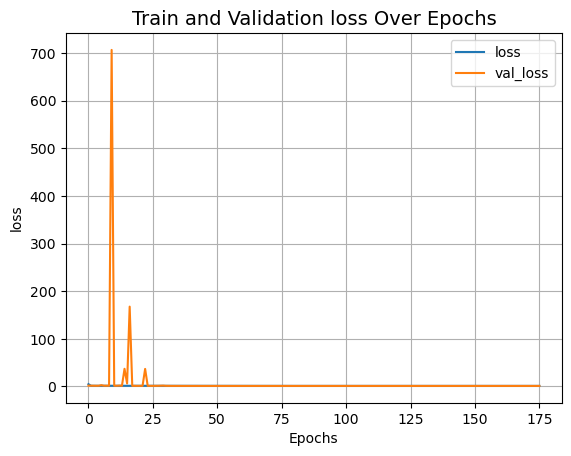

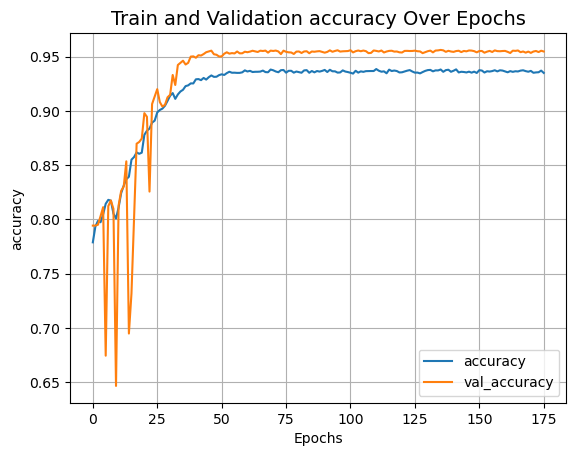

In [14]:
def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_result("loss")
plot_result("accuracy")

In [15]:
# segmentation_model.save('C:/Users/mmdl/Desktop/check_point/Pointnet_model.h5')
# model_json = segmentation_model.to_json()
# with open("C:/Users/mmdl/Desktop/check_point/model_structure.json", "w") as json_file:
#     json_file.write(model_json)

# # 儲存模型權重為HDF5
# segmentation_model.save_weights("C:/Users/mmdl/Desktop/check_point/model_weights.h5")
# tf.saved_model.save(segmentation_model, 'C:/Users/mmdl/Desktop/check_point')

segmentation_model.save('C:/Users/mmdl/Desktop/Jiayuan/check_point/Pointnet_model_test11.h5')

Validation prediction shape: (8, 2048, 3)
Index selected: 0


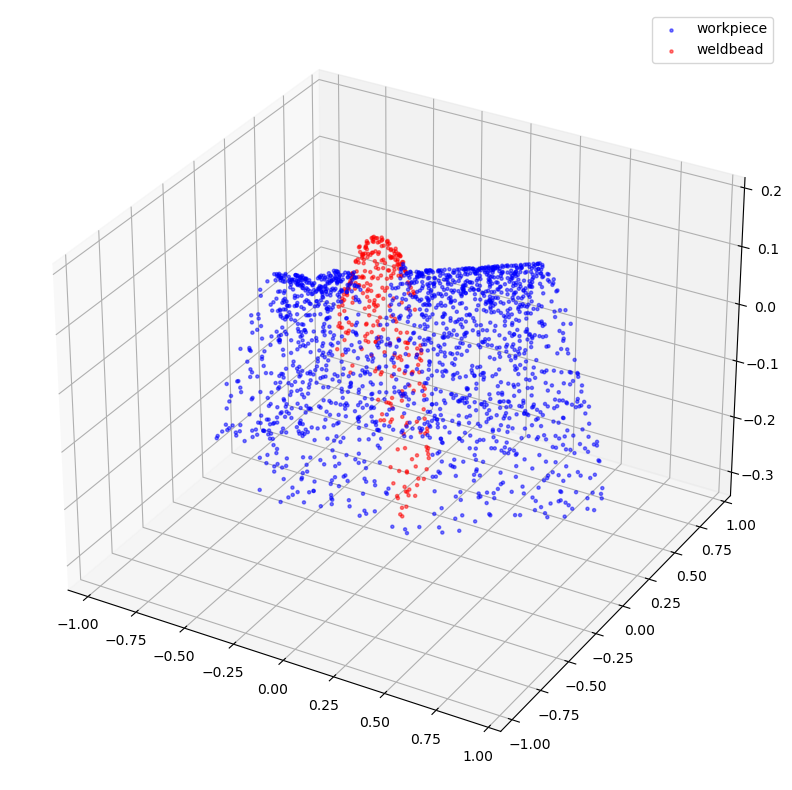

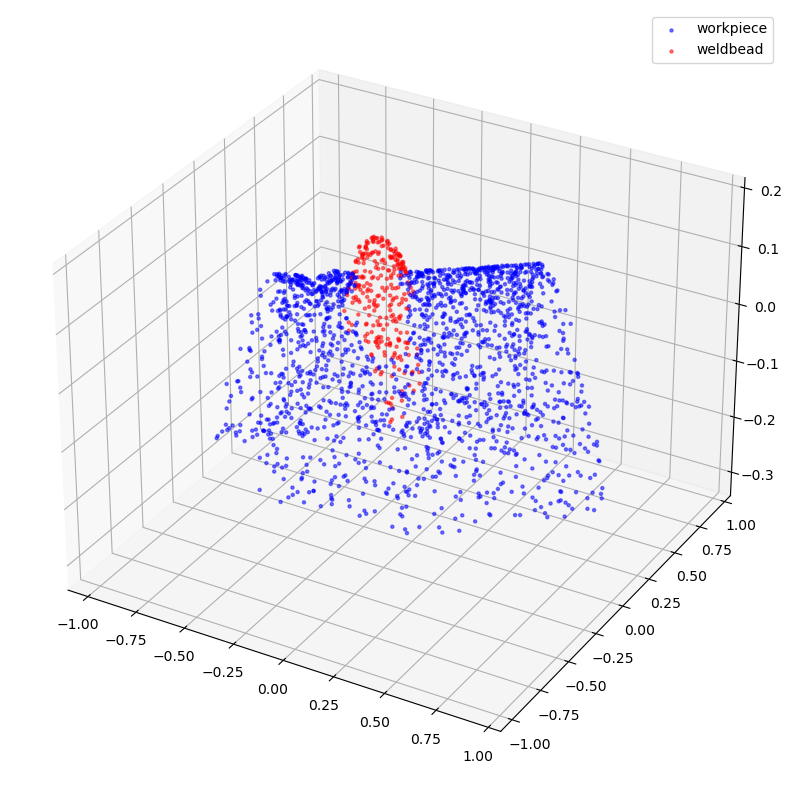

In [16]:
validation_batch = next(iter(val_dataset))
val_predictions = segmentation_model.predict(validation_batch[0])
print(f"Validation prediction shape: {val_predictions.shape}")


def visualize_single_point_cloud(point_clouds, label_clouds, idx):
    label_map = LABELS + ["none"]
    point_cloud = point_clouds[idx]
    label_cloud = label_clouds[idx]
    visualize_data(point_cloud, [label_map[np.argmax(label)] for label in label_cloud])


idx = np.random.choice(len(validation_batch[0]))
print(f"Index selected: {idx}")

# Plotting with ground-truth.
visualize_single_point_cloud(validation_batch[0], validation_batch[1], idx)

# Plotting with predicted labels.
visualize_single_point_cloud(validation_batch[0], val_predictions, idx)

In [17]:
work_piece_file = 'D:/PartAnnotation/00000005/points/3.txt'

cloud = np.loadtxt(work_piece_file)
work_piece_cloud = np.array(cloud[:, :3])
n_points = work_piece_cloud.shape[0]
print(n_points)
print(work_piece_cloud.shape)

mean_point = np.mean(work_piece_cloud, axis=0)
centered_cloud = work_piece_cloud - mean_point

# 归一化
max_norm = np.max(np.linalg.norm(centered_cloud, axis=1))
normalized_cloud = centered_cloud / max_norm

# 更新正規化後的點雲資料
work_piece_cloud = normalized_cloud

500000
(500000, 3)


In [18]:
# 假設你的點雲數據已經加載到變量 `point_cloud` 中
n_p = NUM_SAMPLE_POINTS


# 如果點雲數據的點數超過 1024，隨機選擇 1024 個點
if work_piece_cloud.shape[0] > n_p:
    idx = np.random.choice(work_piece_cloud.shape[0], n_p, replace=False)
    point_cloud_sampled = work_piece_cloud[idx, :]
else:
    # 如果點雲數據的點數小於 1024，用零填充
    padding = np.zeros((n_points - work_piece_cloud.shape[0], work_piece_cloud.shape[1]))
    point_cloud_sampled = np.vstack((work_piece_cloud, padding))

# 確保形狀正確
point_cloud_sampled = point_cloud_sampled.reshape(1, n_p, 3)

# 打印形狀以進行檢查
print(point_cloud_sampled.shape)

# 進行預測
Pointnet_predictions = segmentation_model.predict(point_cloud_sampled)

print(Pointnet_predictions)

labels = np.argmax(Pointnet_predictions, axis=2).flatten()

print(point_cloud_sampled.shape)
print(labels.shape)

(1, 2048, 3)
[[[9.9574727e-01 4.2526801e-03 1.3625215e-07]
  [1.7401767e-01 8.2597727e-01 4.9920036e-06]
  [7.3553503e-01 2.6442084e-01 4.4069369e-05]
  ...
  [9.3484342e-01 6.5097176e-02 5.9378068e-05]
  [9.9981517e-01 1.8446198e-04 3.8851366e-07]
  [9.9488962e-01 5.0579449e-03 5.2388412e-05]]]
(1, 2048, 3)
(2048,)


503


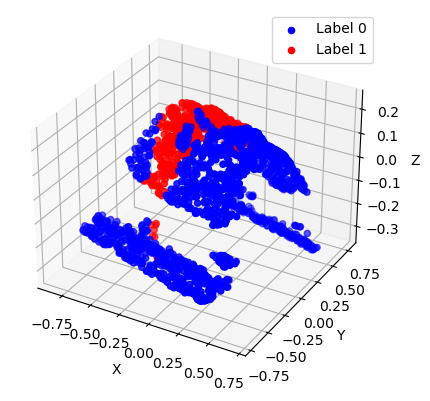

In [19]:
point_cloud_sampled = point_cloud_sampled.reshape(-1, 3)

# Separate points based on labels
points_label0 = point_cloud_sampled[labels == 0]
points_label1 = point_cloud_sampled[labels == 1]

print(len(points_label1))

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot points with different colors based on labels
ax.scatter(points_label0[:, 0], points_label0[:, 1], points_label0[:, 2], c='blue', label='Label 0')
ax.scatter(points_label1[:, 0], points_label1[:, 1], points_label1[:, 2], c='red', label='Label 1')

# Set labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

# Show plot
plt.show()